# Tour de France Data Analysis

## Introduction

This notebook presents the analytical phase of the Tour de France Data Science Project. After scraping and cleaning raw data from the Wikipedia page on Tour de France general classification winners, we now use the neatly structured datasets to answer several research questions.

Each question is approached with well-documented, Pythonic code and summarized conclusions, making the results accessible both for technical and non-technical audiences.

## Research Questions

1. *Which nationality has the most unique Tour de France winners?*  
2. *Which cyclists have won the Tour more three times, and in which years?*  
3. *How long was the shortest Tour de France (in days and kilometers)?*  
4. *How do the winning times of the five-time Tour de France champions compare?*  
5. *At what age did multi-time Tour de France winners claim their victories, and is there a trend in performance as they get older?*

## 1. Which nationality has the most unique Tour de France winners?

### Data, Approach, and Rationale

We use the cleaned nationality summary data (`tdf_winner_nationalities_clean.csv`) previously obtained by scraping the “By nationality” table from Wikipedia.

For this analysis, we will:

- Load the nationality-winners dataset as a list of country records  
- Compare the number of winners per country  
- Determine which country has the highest number of unique winners

In [2]:
import csv

# Define path to the cleaned CSV containing nationality and winner counts
csv_file = 'data/tdf_winner_nationalities_clean.csv'

# Read the CSV file and load data
with open(csv_file, 'r', encoding='utf-8') as f:
    reader = csv.reader(f)
    header = next(reader)  # Skip the header row for correct indexing
    data = [row for row in reader]  # Read all data rows into a list

# Find the country with the maximum number of unique winners
most_unique_winners = max(data, key=lambda x: int(x[2]))

# Output the result in a human-readable sentence
print(f"Country with most unique winners: {most_unique_winners[0]} with {most_unique_winners[2]} winners.")


Country with most unique winners: France with 21 winners.


### Reflection / Interpretation

This analysis reveals that **France** holds the record for most unique Tour de France general classification winners, substantially ahead of other nations. Such statistics highlight the historical dominance of French cyclists in this iconic event.

## 2. Cyclists Who Have Won the Tour More Than Three Times

### Data, Approach, and Rationale

We use the cleaned dataset (`tdf_multiple_winners_clean.json`) previously constructed by scraping the “Multiple winners of the Tour de France general classification” table from Wikipedia.

For this analysis, we will:

- Load the multiple winners JSON dataset containing each cyclist’s name, surname, country, total number of Tour de France victories, and a list of objects describing the years won and corresponding Wikipedia links  
- Filter for cyclists with **four or more total wins**  
- For each, clearly report:
  - Cyclist’s surname and name  
  - Country  
  - Total number of wins  
  - List of years won (and link for more info per year)

In [6]:
import json

# Load the cleaned JSON data of multiple Tour winners
with open('data/tdf_multiple_winners_clean.json', 'r', encoding='utf-8') as f:
    multiple_winners = json.load(f)

# Iterate over the data and print cyclists with more than 3 wins
for winner in multiple_winners:
    if winner['win_count'] > 3:
        # Print basic info: name, country, and total wins
        print(f"The cyclist {winner['surname']} {winner['name']} from {winner['country']} "
              f"won the Tour de France {winner['win_count']} times in the following years:")
        
        # Format and print winning years and links for further info
        year_info = [f"\t{year['year']} for more information click on {year['link']}" for year in winner['wins_years']]
        print(*year_info, sep='\n')

The cyclist Anquetil Jacques from France won the Tour de France 5 times in the following years:
	1957 for more information click on https://en.wikipedia.org/wiki/1957_Tour_de_France
	1961 for more information click on https://en.wikipedia.org/wiki/1961_Tour_de_France
	1962 for more information click on https://en.wikipedia.org/wiki/1962_Tour_de_France
	1963 for more information click on https://en.wikipedia.org/wiki/1963_Tour_de_France
	1964 for more information click on https://en.wikipedia.org/wiki/1964_Tour_de_France
The cyclist Merckx Eddy from Belgium won the Tour de France 5 times in the following years:
	1969 for more information click on https://en.wikipedia.org/wiki/1969_Tour_de_France
	1970 for more information click on https://en.wikipedia.org/wiki/1970_Tour_de_France
	1971 for more information click on https://en.wikipedia.org/wiki/1971_Tour_de_France
	1972 for more information click on https://en.wikipedia.org/wiki/1972_Tour_de_France
	1974 for more information click on ht

### Reflection / Interpretation

This analysis highlights the exceptional athletes in Tour de France history—those who not only achieved repeated success but sustained their dominance over multiple years.

By detailing both the winning years and providing external links, we make it easy to investigate eras of true cycling greatness and the context of each victory.


## 3. How Long Was the Shortest Tour de France (in Days and Kilometers)?

### Data, Approach, and Rationale

We use the cleaned dataset (`tdf_shortest_tour_clean.p`) created by scraping the main winners’ table (“Tour de France general classification winners”) from Wikipedia.

This dataset contains, for every completed edition:

- The year  
- The winner’s full name  
- The winner’s nationality  
- The total distance of the Tour (in kilometers)  
- The winning time or points (depending on the Tour’s rules that year)

For this analysis, we will:

- Load the classification dataset using Pickle, retrieving each year’s distance and time (when available)  
- Convert all usable times to a comparable format (e.g., total hours or days)  
- Identify and display the edition(s) with the smallest total distance  
- Identify and display the edition(s) with the shortest overall winning time

We will clearly report:

- Year  
- Cyclist (winner)  
- Country  
- Distance (in km)  
- Total duration (in hours or days)  

For points-based years, we will indicate them and skip those rows for time comparison.

In [4]:
import pickle

with open('data/tdf_shortest_tour_clean.p', 'rb') as f:
    tours = pickle.load(f)

time_tours = [t for t in tours if t['time_info']['type'] == 'time']

shortest_distance = min(tours, key=lambda x: x['distance_km'])
shortest_time = min(time_tours, key=lambda x: x['time_info']['hours_total'])

print("=== Shortest Total Distance ===")
print(f"Year: {shortest_distance['year']}")
print(f"Cyclist: {shortest_distance['cyclist']}")
print(f"Country: {shortest_distance['country']}")
print(f"Distance: {shortest_distance['distance_km']} km")
print(f"Total: {shortest_distance['time_info']['formatted']} ({shortest_distance['time_info']['type']})")

print("\n=== Shortest Total Time ===")
print(f"Year: {shortest_time['year']}")
print(f"Cyclist: {shortest_time['cyclist']}")
print(f"Country: {shortest_time['country']}")
print(f"Distance: {shortest_time['distance_km']} km")
print(f"Total Time: {shortest_time['time_info']['formatted']}")


=== Shortest Total Distance ===
Year: 1903
Cyclist: Maurice Garin
Country: France
Distance: 2428.0 km
Total: 94h 33′ 14″ (time)

=== Shortest Total Time ===
Year: 2025
Cyclist: Tadej Pogačar*
Country: Slovenia
Distance: 3320.0 km
Total Time: 76h 0′ 32″


### Reflection / Interpretation

This analysis used the cleaned dataset `tdf_shortest_tour_clean.p` to find the Tour de France editions with the shortest distance and the fastest total time.

The data excludes the war years and the 1999–2005 editions affected by Lance Armstrong’s disqualification. If those years had counted, the results might have been different.

Thanks to this cleaning, we can clearly see which editions were the shortest and fastest — showing how the race has changed over time and how history has influenced the Tour itself.


## 4. How do the winning times of the five-time Tour de France champions compare?

### Data, Approach, and Rationale

- Jacques Anquetil  
- Eddy Merckx  
- Bernard Hinault  
- Miguel Induráin

Using the cleaned JSON data for these riders, we will extract the winning times from each of their five victories.

The analysis consists of the following steps:

- Parse the JSON file to collect each winner's five `"winning_time"` values  
- Convert all winning times from the `"hh mm ss"` string format to total minutes, so that all results are directly comparable  
- For each rider, present the five victory times as individual bars in a grouped bar chart, using Matplotlib  
- The X-axis of the chart will represent the cyclists’ names, with five bars per cyclist corresponding to their wins in chronological order  
- The Y-axis will show the total time (in minutes) it took to win the Tour for each victory

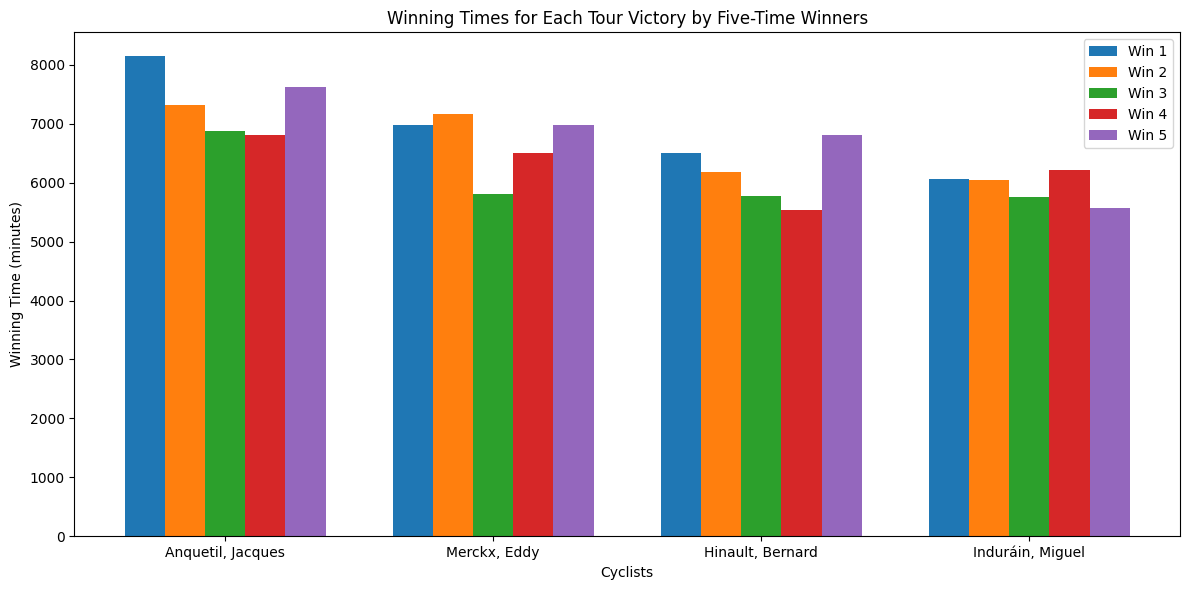

In [5]:
import json
import re
import numpy as np
import matplotlib.pyplot as plt

def time_str_to_minutes(time_str):
    pattern = r"(\d+)h\s*(\d+)'?\s*(\d+)?"
    match = re.match(pattern, time_str)
    if match:
        hours = int(match.group(1))
        minutes = int(match.group(2))
        seconds = int(match.group(3)) if match.group(3) else 0
        return hours * 60 + minutes + seconds / 60

# Load your JSON data
with open('data/tdf_five_timers_clean.json', 'r', encoding='utf-8') as file:
    data = json.load(file)

cyclists = []
all_times = []
win_labels = ['Win 1', 'Win 2', 'Win 3', 'Win 4', 'Win 5']

for cyclist_record in data:
    cyclists.append(cyclist_record['cyclist'])
    times = [time_str_to_minutes(victory['winning_time']) for victory in cyclist_record['victories']]
    all_times.append(times)

num_wins = 5
bar_width = 0.15
x = np.arange(len(cyclists))

fig, ax = plt.subplots(figsize=(12, 6))

for i in range(num_wins):
    win_times = [times[i] for times in all_times]
    ax.bar(x + i * bar_width, win_times, width=bar_width, label=win_labels[i])

ax.set_xticks(x + bar_width * (num_wins - 1) / 2)
ax.set_xticklabels(cyclists)
ax.set_xlabel('Cyclists')
ax.set_ylabel('Winning Time (minutes)')
ax.set_title('Winning Times for Each Tour Victory by Five-Time Winners')
ax.legend()
plt.tight_layout()
plt.show()


### Reflection / Interpretation

This grouped bar chart clearly shows the total number of minutes each legendary cyclist spent winning each of their five Tours. It is immediately visible that Jacques Anquetil generally needed more time in his wins compared to the others, while Miguel Induráin achieved consistently faster victories with lower total times across all his wins. Thanks to this plot, we see not only who dominated in total wins, but also whose victories were most time-efficient.